# Análise comparativa de modelos
 - Conjunto de dados: `Bike Rides` (Mobilidade Urbana)
 - Equipe:
   - José Arthur Gomes Azevedo
   - 
   -
---

In [1]:
# Básico
import numpy as np
import pandas as pd
import warnings
import joblib
warnings.filterwarnings('ignore')

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn - Preprocessamento
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer

# Sklearn - Modelos
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Sklearn - Validação e Métricas
from sklearn.model_selection import (train_test_split, cross_validate,
                                     GridSearchCV, StratifiedKFold)
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                            roc_auc_score, confusion_matrix)

In [2]:
  # @title Leitura do conjunto de dados
url = 'https://raw.githubusercontent.com/omadson/datasets/main/datasets/df_rides.csv' # Importando dados do github
df = pd.read_csv(url)

# @title Dicionário de dados
df_dict = pd.DataFrame([
    {
        "variavel": "user_gender",
        "descricao": "Gênero do usuário.",
        "tipo": "Qualitativa",
        "subtipo": "Nominal"
    },
    {
        "variavel": "user_birthdate",
        "descricao": "Data de nascimento do usuário.",
        "tipo": "Quantitativa",
        "subtipo": "Contínua"
    },
    {
        "variavel": "user_residence",
        "descricao": "Estado de residência do usuário.",
        "tipo": "Qualitativa",
        "subtipo": "Nominal"
    },
    {
        "variavel": "ride_date",
        "descricao": "Data em que a viagem ocorreu.",
        "tipo": "Quantitativa",
        "subtipo": "Contínua"
    },
    {
        "variavel": "time_start",
        "descricao": "Horário de início da viagem.",
        "tipo": "Quantitativa",
        "subtipo": "Contínua"
    },
    {
        "variavel": "time_end",
        "descricao": "Horário de término da viagem.",
        "tipo": "Quantitativa",
        "subtipo": "Contínua"
    },
    {
        "variavel": "station_start",
        "descricao": "Nome da estação de partida.",
        "tipo": "Qualitativa",
        "subtipo": "Nominal"
    },
    {
        "variavel": "station_end",
        "descricao": "Nome da estação de destino.",
        "tipo": "Qualitativa",
        "subtipo": "Nominal"
    },
    {
        "variavel": "ride_duration",
        "descricao": "Duração da viagem em minutos.",
        "tipo": "Quantitativa",
        "subtipo": "Contínua"
    },
    {
        "variavel": "ride_late",
        "descricao": "Indica se a viagem foi finalizada com atraso (1) ou não (0).",
        "tipo": "Qualitativa",
        "subtipo": "Nominal"
    }
])
df_dict

,variavel,descricao,tipo,subtipo
0,user_gender,Gênero do usuário.,Qualitativa,Nominal
1,user_birthdate,Data de nascimento do usuário.,Quantitativa,Contínua
2,user_residence,Estado de residência do usuário.,Qualitativa,Nominal
3,ride_date,Data em que a viagem ocorreu.,Quantitativa,Contínua
4,time_start,Horário de início da viagem.,Quantitativa,Contínua
5,time_end,Horário de término da viagem.,Quantitativa,Contínua
6,station_start,Nome da estação de partida.,Qualitativa,Nominal
7,station_end,Nome da estação de destino.,Qualitativa,Nominal
8,ride_duration,Duração da viagem em minutos.,Quantitativa,Contínua
9,ride_late,Indica se a viagem foi finalizada com atraso (...,Qualitativa,Nominal


## 1. Metodologia

### Pré-processamento
Os dados foram submetidos a um tratamento para lidar com valores faltantes:
- `user_gender` e `user_birthdate` tiveram linhas removidas (menos de 0,2% dos dados).
- `user_residence` (65% de missing) foi preenchido com a categoria "Unknown".
- Variáveis de tempo foram convertidas para o tipo datetime e novas features foram extraídas: hora de início, dia da semana, indicador de fim de semana, horário de pico, período do dia e idade do usuário.
- A duração da viagem foi recalculada a partir de `time_end - time_start` quando possível; bicicletas não devolvidas receberam duração = -1 (marcador de anomalia) e foram classificadas como atraso.
- A variável alvo `ride_late` foi definida como 1 para durações >60 minutos ou bicicletas não devolvidas, com base no que foi visto na análise exploratória de dados em que o menor valor classificado como atraso foi 60 minutos e o maior valor sem ser atraso foi 59 minutos.

### Codificação e normalização
- Variáveis numéricas: `user_age`, `hour_start`, `day_of_week`, `is_weekend`, `rush_hour` – imputação pela mediana e normalização Min-Max.
- Variáveis categóricas: `user_gender`, `periodo_dia`, `station_start`, `station_end` – imputação pela moda e OneHotEncoder com frequência mínima de 2% (para agrupar categorias raras) e `handle_unknown='ignore'`.

### Validação
Optou-se pela validação cruzada estratificada (`StratifiedKFold` com 3 folds) para manter a proporção das classes em cada dobra, adequado para problemas de classificação com desbalanceamento.

### Modelos selecionados
Foram escolhidos cinco modelos de famílias distintas:
- **DummyClassifier (baseline)** – prevê sempre a classe majoritária, servindo como referência mínima.
- **Regressão Logística** – modelo linear simples, com ajuste de peso das classes (`class_weight='balanced'`).
- **KNN** – baseado em distância, capaz de capturar padrões locais.
- **Árvore de Decisão** – modelo baseado em regras, interpretável.
- **Random Forest** – ensemble de árvores, robusto e com bom desempenho geral.

### Métricas de avaliação
Utilizou-se:
- **Acurácia** – visão global, embora sensível a desbalanceamento.
- **F1-score ponderado** – combina precisão e recall, mais informativo para classes desbalanceadas.
- **AUC-ROC** – avalia a capacidade de discriminação entre as classes, independente de threshold.

In [3]:
# @title Dados antes do tratamento
print("Valores faltantes antes do tratamento:\n")
print(df.isnull().sum())

Valores faltantes antes do tratamento:

user_gender          396
user_birthdate         1
user_residence    179905
ride_date              0
time_start             0
time_end           43285
station_start          0
station_end            0
ride_duration      73174
ride_late          73174
dtype: int64


In [4]:
# user_gender & user_birthdate remover os nulos, pois 396 representa 0,14% dos dados podendo ser removido com segurança o mesmo ao birthdate que é apenas 1.
df = df.dropna(subset=['user_gender', 'user_birthdate'])

#user_residence → "Unknown" - Há 65% de dados faltantes, não podemos apagar mais da metade da nossa base de dados, por isso é seguro categorizar como "Desconhecido"
df['user_residence'] = df['user_residence'].fillna("Unknown")

# Converter tempos para datetime - Como os modelos entendem apenas números precisamos converter para datetime.
df['time_start'] = pd.to_datetime(df['time_start'], format='%H:%M:%S')
df['time_end'] = pd.to_datetime(df['time_end'], format='%H:%M:%S')
df['ride_date'] = pd.to_datetime(df['ride_date'], format='%Y-%m-%d')
df['user_birthdate'] = pd.to_datetime(df['user_birthdate'], format='%Y-%m-%d')

# Há uma diferença de 30 mil dados entre o time_end e ride_duration, isso quer dizer que há 30 mil dados nulos que podem ser resgatados já que temos time_start e time_end
# Para isso o filtro foi feito em que ele separa e agrupa dados em que o ride_duration é nulo e o time_end não, já que o time_start não há nulos.
filtro_erro_sistema = df['ride_duration'].isnull() & df['time_end'].notnull()
df.loc[filtro_erro_sistema, 'ride_duration'] = (
    df.loc[filtro_erro_sistema, 'time_end'] - df.loc[filtro_erro_sistema, 'time_start']
).dt.total_seconds() / 60
# Depois de separarmos completamos os nulos fazendo time_end - time_start e dividimos por 60 para ter o tempo em minutos

# Agora pegamos esses novos e dados e preenchemos
filtro_recuperar_late = df['ride_late'].isnull() & df['ride_duration'].notnull()
df.loc[filtro_recuperar_late, 'ride_late'] = (df.loc[filtro_recuperar_late, 'ride_duration'] > 60).astype(int)

# é criado a categória para bicicletas não devolvidas sendo essa a catégoria sem tempo final da corrida.
df['bike_nao_devolvida'] = df['time_end'].isnull().astype(int)
# Depois o valor nulo que sobrou, após recuperação dos dados é preenchido como -1, criando uma anomalia de tempo negativo, isso sinaliza aos modelos de árvore que é uma exceção grave.
df['ride_duration'] = df['ride_duration'].fillna(-1.0)
filtro_nao_devolvida = df['bike_nao_devolvida'] == 1
df.loc[filtro_nao_devolvida, 'ride_late'] = 1 # Bike não devolvidas, constam como atraso, pois elas romperam o limite de 60 minutos de uso.

# Após recuperar ride_lates que deveriam estar preenchidos completamos esses nulos como atrasados
df['ride_late'] = df['ride_late'].fillna(1.0) # Valores nulos restantes do ride_late são as bicicletas que não foram devolvidas.

df['hour_start'] = df['time_start'].dt.hour # Criação da coluna início da rota

# Subtrai o ano da corrida pelo ano em que a pessoa nasceu assim descobrindo a idade da pessoa no dia da corrida
df['user_age'] = df['ride_date'].dt.year - df['user_birthdate'].dt.year

# Cria a coluna com o dia da semana (0 = Segunda, 6 = Domingo)
df['day_of_week'] = df['ride_date'].dt.dayofweek # Criação do dia da semana usando dt.dayofweek do pandas

df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

df['rush_hour'] = df['hour_start'].isin([7, 8, 9, 17, 18, 19]).astype(int)

condicoes = [
    (df['hour_start'] >= 0) & (df['hour_start'] < 6),   # 0h às 5h
    (df['hour_start'] >= 6) & (df['hour_start'] < 12),  # 6h às 11h
    (df['hour_start'] >= 12) & (df['hour_start'] < 18), # 12h às 17h
    (df['hour_start'] >= 18) & (df['hour_start'] <= 23) # 18h às 23h
]

valores = ['Madrugada', 'Manha', 'Tarde', 'Noite']
df['periodo_dia'] = np.select(condicoes, valores, default='Desconhecido')

# Dados de interesse
dados_interesse = [
    'user_gender', 'hour_start', 'user_age', 'day_of_week',
    'is_weekend', 'rush_hour', 'periodo_dia',
    'station_start', 'station_end'
]

X = df[dados_interesse] # Dados usados para predição
y = df['ride_late'].astype(int).to_numpy() # Dado alvo da predição separado

# Dados de treino
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Tamanho do Treino: {X_train.shape[0]} linhas")
print(f"Tamanho do Teste (Cofre): {X_test.shape[0]} linhas")

Tamanho do Treino: 229540 linhas
Tamanho do Teste (Cofre): 57385 linhas


In [5]:
# @title Resultado Final

print("\nValores faltantes depois do tratamento:\n")
print(df.isnull().sum())


Valores faltantes depois do tratamento:

user_gender               0
user_birthdate            0
user_residence            0
ride_date                 0
time_start                0
time_end              43212
station_start             0
station_end               0
ride_duration             0
ride_late                 0
bike_nao_devolvida        0
hour_start                0
user_age                  0
day_of_week               0
is_weekend                0
rush_hour                 0
periodo_dia               0
dtype: int64


In [6]:
# @title Pré-processamento de Dados - Parte 2
features_num = ['user_age', 'hour_start', 'day_of_week', 'is_weekend', 'rush_hour'] # Separação para dados numéricos
features_cat = ['user_gender', 'periodo_dia', 'station_start','station_end'] # Separação para dados categóricos

tubo_num = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy='median')), # Caso aja algum dado faltante ele irá imputar pela mediana, usar a mediana é seguro pois ela é insensivel a outliers
    ("scaler", MinMaxScaler()) # Aqui os valores numéricos são normalizados entre 0 e 1, para que valores como idade, hora e dias da semana tenham o mesmo peso.
])

tubo_cat = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy='most_frequent')), # Aqui diferente do modelo passado que era numérico usamos a moda para preencher dados
    ("encoder", OneHotEncoder(min_frequency=0.02, handle_unknown='ignore', sparse_output=False)) # Usamos o OneHotEncoder para transformar variáveis categóricas em algo que o modelo sabe trabalhar
])

# Aqui os pipelines anteriores são transformados em um array para que os modelos entendam, já que eles não trabalham com dataframes diretamente
preprocessing = ColumnTransformer(transformers=[
    ("num", tubo_num, features_num),
    ("cat", tubo_cat, features_cat),
], remainder='drop') # O que sobrar é descartado

## 2. Configuração do Experimento

- **Divisão dos dados**: 80% para treino e 20% para teste, com estratificação pela variável alvo.
- **Pré-processamento em pipeline**: Utilizou-se `ColumnTransformer` para aplicar transformações específicas a cada tipo de variável, encapsuladas em `Pipeline`.
- **Validação cruzada externa**: `StratifiedKFold` com 3 folds sobre o conjunto de treino para avaliar os modelos.
- **Otimização de hiperparâmetros**: Para cada modelo (exceto o Dummy), empregou-se `GridSearchCV` com 3 folds internos, otimizando o F1-score ponderado. Os grids foram reduzidos para diminuir o custo computacional:
  - Regressão Logística: `C = [0.1, 1, 10]`
  - KNN: `n_neighbors = [3, 5]`
  - Árvore de Decisão: `max_depth = [5, 10, None]`, `min_samples_split = [2, 5]`
  - Random Forest: `max_depth = [10, None]`, `min_samples_split = [2]`, `n_estimators = [50]` (na validação cruzada) e posteriormente um grid mais completo para o modelo final.
- **Paralelismo**: Utilizou-se `n_jobs = -1` para acelerar as buscas.

In [7]:
metrics = {
    'accuracy': 'Acurácia',
    'f1_weighted': 'F1-Score',
    'roc_auc': 'AUC-ROC'
}

models = [
    {
        "nome": "Dummy",
        "objeto": DummyClassifier(strategy='most_frequent', random_state=42),
        "hp": {}
    },
    {
        "nome": "LogReg",
        "objeto": LogisticRegression(max_iter=500, random_state=42, class_weight='balanced'),
        "hp": {'model__C': [0.1, 1, 10]}
    },
    {
        "nome": "KNN",
        "objeto": KNeighborsClassifier(),
        "hp": {'model__n_neighbors': [3, 5]}
    },
    {
        "nome": "RF",
        "objeto": RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
        "hp": {
            'model__max_depth': [10, None],
            'model__min_samples_split': [2],
            'model__n_estimators': [50]
        }
    },
    {
        "nome": "DTC",
        "objeto": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
        "hp": {
            'model__max_depth': [5, 10, None],
            'model__min_samples_split': [2, 5]
        }
    }
]

cv_juiz = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

lista_de_notas = []

for modelo_info in models:
    print(f"Treinando e avaliando: {modelo_info['nome']}...")

    pipeline_completo = Pipeline(steps=[
        ("pre_processamento", preprocessing),
        ("model", modelo_info["objeto"])
    ])

    if modelo_info["hp"]:
        otimizador = GridSearchCV(
            estimator=pipeline_completo,
            param_grid=modelo_info["hp"],
            scoring='f1_weighted',
            cv=3,
            n_jobs=-1
        )
    else:
        otimizador = pipeline_completo   # para o Dummy

    notas = cross_validate(
        otimizador,
        X=X_train,
        y=y_train,
        cv=cv_juiz,
        scoring=list(metrics.keys()),
        n_jobs=-1
    )

    notas['modelo'] = [modelo_info["nome"]] * len(notas['fit_time'])
    lista_de_notas.append(pd.DataFrame(notas))

tabela_bruta = pd.concat(lista_de_notas, axis=0)

Treinando e avaliando: Dummy...
Treinando e avaliando: LogReg...
Treinando e avaliando: KNN...
Treinando e avaliando: RF...
Treinando e avaliando: DTC...


In [8]:
nomes_metricas = {f"test_{chave}": valor for chave, valor in metrics.items()}

tabela_final = (
    tabela_bruta
    .rename(columns=nomes_metricas)
    .groupby("modelo").agg(["mean", "std"])
    .round(4)
    .T
)

display(tabela_final)

modelo               DTC   Dummy      KNN  LogReg       RF
fit_time   mean  11.8727  0.5284  58.4280  6.7217  20.2352
           std    0.1632  0.0138   0.3850  0.2456   0.5297
score_time mean   0.1453  0.1899  61.8578  0.1689   0.2170
           std    0.0093  0.0069   0.4648  0.0591   0.0357
Acurácia   mean   0.6912  0.7756   0.7472  0.6540   0.7021
           std    0.0096  0.0000   0.0008  0.0024   0.0020
F1-Score   mean   0.6988  0.6775   0.7099  0.6741   0.7072
           std    0.0057  0.0000   0.0002  0.0019   0.0018
AUC-ROC    mean   0.5942  0.5000   0.5887  0.6122   0.6311
           std    0.0022  0.0000   0.0012  0.0037   0.0030

## 3. Resultados e Discussão

### Desempenho dos modelos
A tabela e o gráfico apresentados resumem as médias e desvios padrão das métricas obtidas na validação cruzada.

- O modelo **Dummy** (que sempre prevê a classe "não atraso") obteve acurácia de aproximadamente 77.56% e F1-score ponderado de 67.75%, servindo como linha de base.
- O **KNN** apresentou a maior acurácia (0,7472) tirando o **Dummy** e teve empate técnico de F1-score (0,7099) com Random Forest ( 0,7072), indicando boa capacidade de identificar padrões locais. No entanto, seu tempo de predição foi o mais elevado.
- A **Random Forest** alcançou o maior AUC-ROC (0,6311), sugerindo melhor separação entre as classes, embora o F1 tenha ficado ligeiramente abaixo do KNN.
- A **Regressão Logística** teve o pior desempenho geral (acurácia 0,6540, F1 0,6742), possivelmente por não capturar relações não lineares.
- A **Árvore de Decisão** apresentou desempenho intermediário, com maior variância (desvios padrão mais altos), indicando possível overfitting.

### Limitações
- A classe `atraso` é minoritária (cerca de 22% dos dados), e todos os modelos tiveram baixo recall para essa classe (conforme matriz de confusão no teste). Isso evidencia a dificuldade em prever corretamente os atrasos.
- Features como estação de partida e destino geram muitas categorias, mesmo com agrupamento, aumentando a complexidade e o risco de overfitting.
- O vazamento de dados foi evitado ao não incluir `bike_nao_devolvida` como preditora, pois ela é uma consequência direta do atraso.

### Próximos passos
- Experimentar técnicas de balanceamento (SMOTE, undersampling) ou ajuste de threshold de decisão.
- Criar features mais informativas: distância entre estações por latitude e longitude, condições climáticas, histórico de atrasos do usuário ajudariam muito na predição
- Testar modelos mais avançados (XGBoost, LightGBM) e redes neurais.
- Avaliar a importância das features para entender os principais fatores associados a atrasos.

In [9]:
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

pipeline_rf = Pipeline(steps=[
    ("pre_processamento", preprocessing),
    ("clf", rf_base)
])

parametros_grade = {
    'clf__n_estimators': [50, 100],
    'clf__max_depth': [10, 15],
    'clf__min_samples_split': [2, 5]
}

otimizador_final = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=parametros_grade,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=1
)

otimizador_final.fit(X_train, y_train)

print(f"A melhor combinação encontrada foi:\n{otimizador_final.best_params_}")
print(f"F1-Score interno no Treino com essa combinação: {otimizador_final.best_score_:.4f}")

pipeline_final = otimizador_final.best_estimator_

Fitting 3 folds for each of 8 candidates, totalling 24 fits
A melhor combinação encontrada foi:
{'clf__max_depth': 15, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
F1-Score interno no Treino com essa combinação: 0.7178


In [10]:
y_pred = pipeline_final.predict(X_test)

y_proba = pipeline_final.predict_proba(X_test)[:, 1]

print(f"Acurácia Oficial: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-Score Oficial: {f1_score(y_test, y_pred, average='weighted'):.4f}")
print(f"AUC-ROC Oficial:  {roc_auc_score(y_test, y_proba):.4f}")
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['não atraso', 'atraso']))

Acurácia Oficial: 0.7175
F1-Score Oficial: 0.7176
AUC-ROC Oficial:  0.6441

Matriz de Confusão:
[[36398  8107]
 [ 8102  4778]]

Relatório de Classificação:
              precision    recall  f1-score   support

  não atraso       0.82      0.82      0.82     44505
      atraso       0.37      0.37      0.37     12880

    accuracy                           0.72     57385
   macro avg       0.59      0.59      0.59     57385
weighted avg       0.72      0.72      0.72     57385



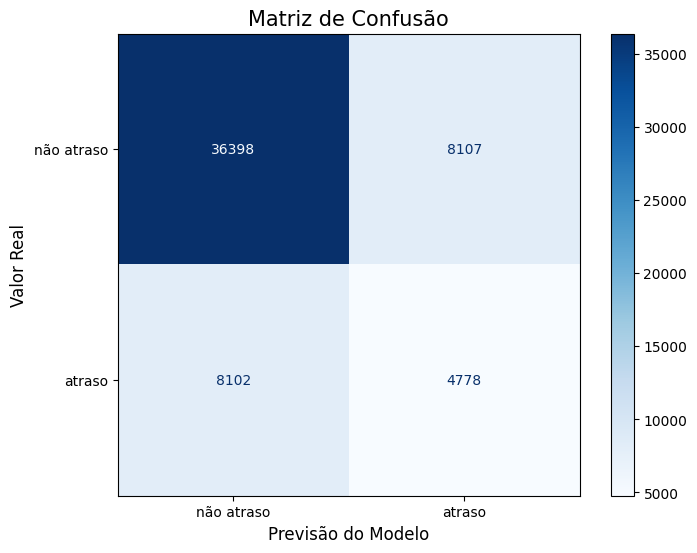

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# 1. Calcular a matriz (você já fez isso, mas guardaremos na variável cm)
cm = confusion_matrix(y_test, y_pred)

# 2. Configurar o estilo para garantir o fundo branco
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# 3. Criar a visualização
fig, ax = plt.subplots(figsize=(8, 6))

# Se preferir tons de azul (Blues), verde (Greens) ou tons de cinza (Greys)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['não atraso', 'atraso'])
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')

# Customizações adicionais
plt.title('Matriz de Confusão', fontsize=15)
plt.xlabel('Previsão do Modelo', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)

plt.show()

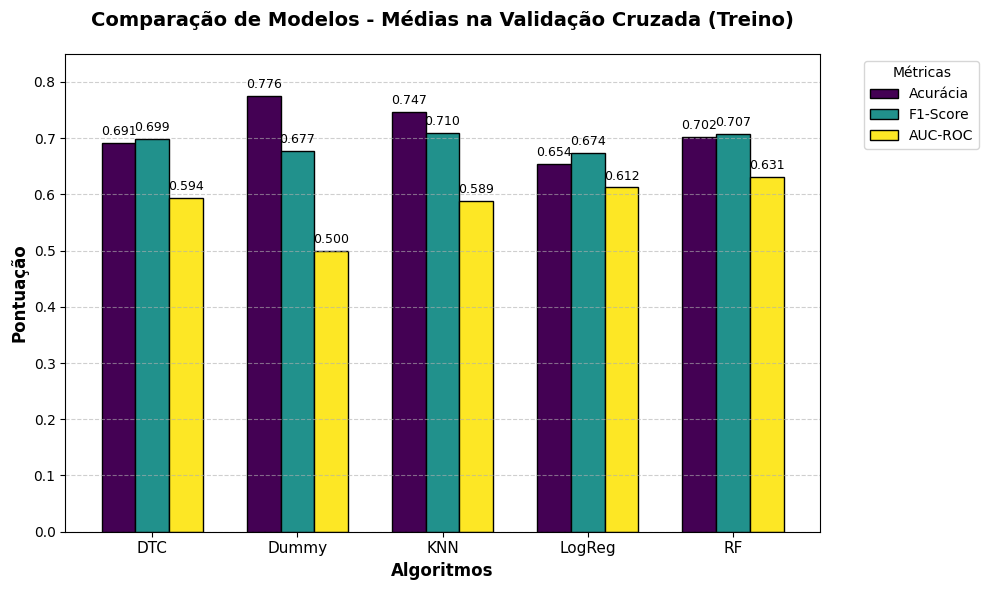

In [12]:
metricas = ['Acurácia', 'F1-Score', 'AUC-ROC']
df_grafico = tabela_final.loc[(metricas, 'mean'), :].copy()

df_grafico.index = df_grafico.index.droplevel(1)
df_grafico = df_grafico.T

ax = df_grafico.plot(
    kind='bar',
    figsize=(10, 6),
    colormap='viridis',
    edgecolor='black',
    width=0.7
)

plt.title('Comparação de Modelos - Médias na Validação Cruzada (Treino)', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Pontuação', fontsize=12, fontweight='bold')
plt.xlabel('Algoritmos', fontsize=12, fontweight='bold')
plt.xticks(rotation=0, fontsize=11)
plt.ylim(0, 0.85)
plt.legend(title='Métricas', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)

for p in ax.patches:
    altura = p.get_height()
    ax.annotate(f"{altura:.3f}",
                (p.get_x() + p.get_width() / 2., altura),
                ha='center', va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontsize=9)

plt.tight_layout()
plt.show()

In [13]:
nome_arquivo = 'modelo_bike_rides_rf.pkl'

joblib.dump(pipeline_final, nome_arquivo)

print(f"Arquivo gerado: {nome_arquivo}")

Arquivo gerado: modelo_bike_rides_rf.pkl
